
# 03. 부품을 순서대로 키우기: 읽기 → 판단 → 함께 다듬기

규칙 세계 v1, 처음 보는 조합(composition), seed 42–45. 언어 부품은 mDeBERTa-NLI, 판단 부품은 출처 구조 판단기다.

| 단계 | 하는 일 | 학습되는 것 |
|---|---|---|
| 1. 읽기 | 언어 부품 + **단순** 판단기를 최종 답만으로 함께 학습 (4에폭) | 언어 부품, 단순 판단기 |
| 2. 판단 | 1단계 언어 부품을 **고정**하고 **출처 구조** 판단기를 새로 학습 (8에폭) | 출처 구조 판단기만 |
| 3. 함께 다듬기 | 2단계의 두 부품에서 출발해 **둘 다** 작은 학습률로 함께 미세조정 (3에폭) | 둘 다 |

**기준선**: 출처 구조 판단기가 사람이 설계한 정답 메시지를 받으면 seed 4개 모두 1.00이다.

> **정정 (대조 실험 후)**: 처음 이 노트북을 쓸 때는 "처음부터 두 부품을 같이 학습하면 멈춘다"고 적었다(seed 42 하나 기준). seed 4개로 대조하자 2개는 멈추고(−0.11, −0.31) 2개는 잘 학습됐다(0.91, 1.00). 자세한 내용은 노트북 04에 있다.

**점검**: 모든 2·3단계 결과는 저장한 부품을 다시 불러와 같은 점수가 나오는지 확인했다(`world/interface_checks.py`). 고정된 언어 부품의 메시지는 fp32로 계산한다(bf16 버그 수정 뒤의 결과다).


In [1]:

import statistics
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = [42, 43, 44, 45]
STAGES = [("1. 읽기", "interface-anchored-learned"),
          ("2. 판단", "interface-anchored-learned-sourcefold-staged-frozen"),
          ("3. 함께 다듬기", "interface-anchored-learned-sourcefold-staged-tuned")]
runs = {name: {s: S.interface_result(stem, seed=s) for s in SEEDS} for name, stem in STAGES}



## 1. seed마다의 성장 과정


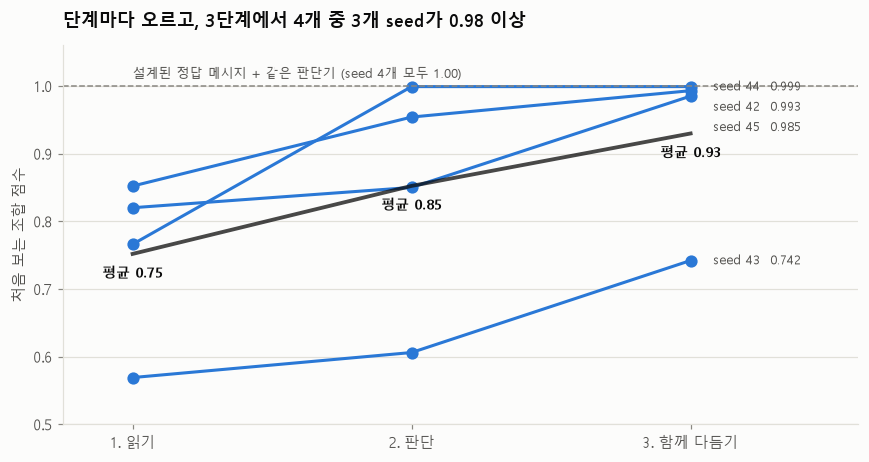

In [2]:

fig, ax = plt.subplots(figsize=(8, 4.3))
finals = {}
for s in SEEDS:
    ys = [runs[name][s]["score"] for name, _ in STAGES]
    ax.plot(range(3), ys, "-o", color=V.BLUE, markersize=7)
    finals[s] = ys[-1]
# Spread end labels so close final scores do not overlap (at least 0.03 apart, top down).
placed = {}
for s in sorted(finals, key=finals.get, reverse=True):
    y = finals[s]
    if placed:
        y = min(y, min(placed.values()) - 0.03)
    placed[s] = y
    ax.text(2.08, y, f"seed {s}  {finals[s]:.3f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axhline(1.0, color=V.MUTED, linestyle="--", linewidth=1)
ax.text(0, 1.008, "설계된 정답 메시지 + 같은 판단기 (seed 4개 모두 1.00)", fontsize=8.5, color=V.TEXT_SECONDARY, va="bottom")
means = [statistics.mean(runs[name][s]["score"] for s in SEEDS) for name, _ in STAGES]
ax.plot(range(3), means, "-", color=V.TEXT, linewidth=2.5, alpha=0.75)
for i, m in enumerate(means):
    ax.text(i, m - 0.035, f"평균 {m:.2f}", ha="center", fontsize=9, color=V.TEXT, fontweight="bold")
ax.set_xticks(range(3), [name for name, _ in STAGES])
ax.set_xlim(-0.25, 2.6)
ax.set_ylim(0.5, 1.06)
ax.grid(axis="x", visible=False)
ax.set_ylabel("처음 보는 조합 점수")
ax.set_title("단계마다 오르고, 3단계에서 4개 중 3개 seed가 0.98 이상", pad=12)
fig.tight_layout()
plt.show()



## 2. 단계 사이의 차이 (seed 짝 비교, 점은 평균, 선은 95% 신뢰구간)

선이 0을 넘지 않고 오른쪽에 있으면 확실히 나아진 것이다.


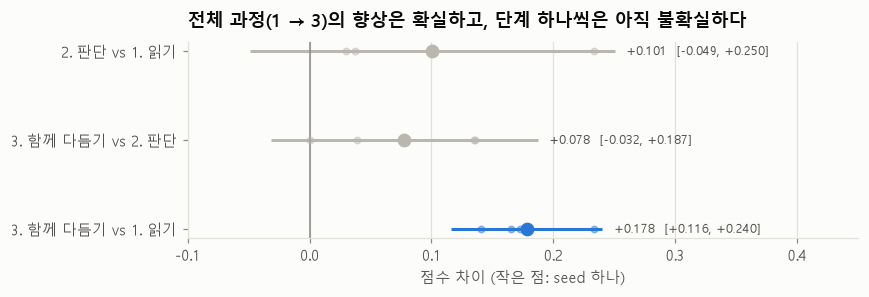

In [3]:

pairs = [("2. 판단 vs 1. 읽기", 1, 0), ("3. 함께 다듬기 vs 2. 판단", 2, 1), ("3. 함께 다듬기 vs 1. 읽기", 2, 0)]
fig, ax = plt.subplots(figsize=(8, 2.8))
for i, (label, a, b) in enumerate(pairs):
    diffs = [runs[STAGES[a][0]][s]["score"] - runs[STAGES[b][0]][s]["score"] for s in SEEDS]
    mean, half = S.mean_ci(diffs)
    color = V.BLUE if mean - half > 0 else V.NEUTRAL
    ax.errorbar(mean, i, xerr=half, fmt="o", color=color, markersize=8, elinewidth=2, capsize=0)
    ax.scatter(diffs, [i] * len(diffs), s=18, color=color, alpha=0.45, zorder=3)
    ax.text(mean + half + 0.01, i, f"{mean:+.3f}  [{mean - half:+.3f}, {mean + half:+.3f}]", va="center",
            fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axvline(0, color=V.MUTED, linewidth=1)
ax.set_yticks(range(len(pairs)), [p[0] for p in pairs])
ax.invert_yaxis()
ax.set_xlim(-0.1, 0.45)
ax.grid(axis="y", visible=False)
ax.set_xlabel("점수 차이 (작은 점: seed 하나)")
ax.set_title("전체 과정(1 → 3)의 향상은 확실하고, 단계 하나씩은 아직 불확실하다", pad=10)
fig.tight_layout()
plt.show()



## 3. 사례 종류별로 무엇이 고쳐졌나

파랑은 맞힘(+1), 회색은 0, 빨강은 틀림(−1)이다. seed마다 세 줄(1·2·3단계)이다.


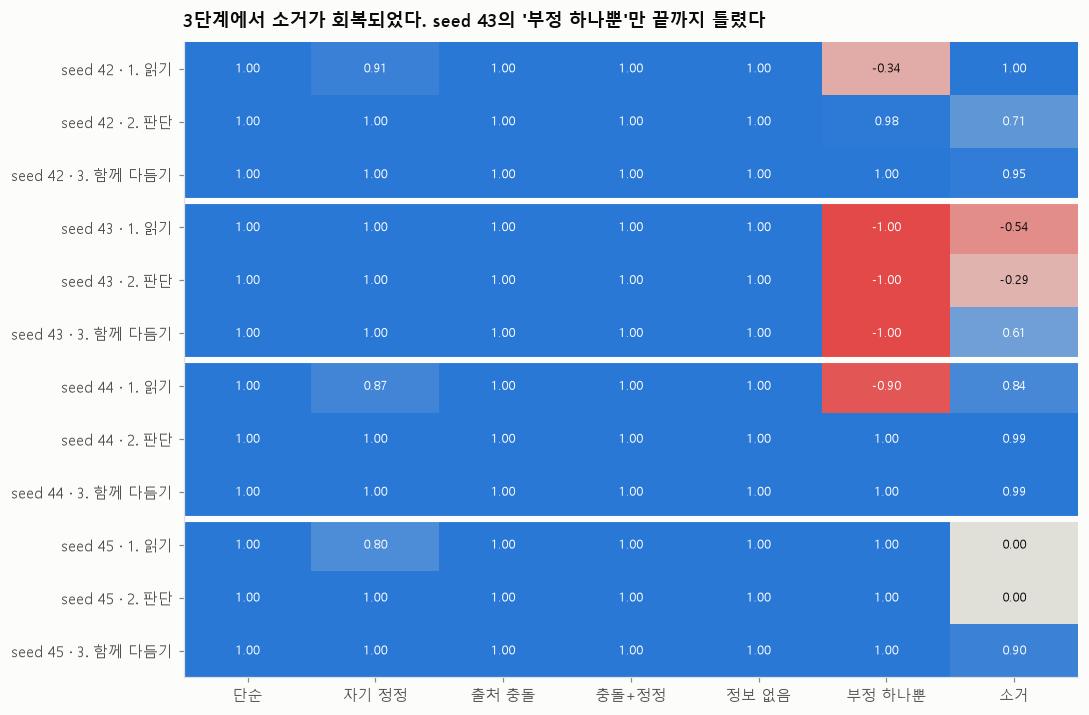

In [4]:

cases = ["simple", "self_correction", "conflict", "conflict_correction", "none", "one_negative", "elimination"]
case_names = ["단순", "자기 정정", "출처 충돌", "충돌+정정", "정보 없음", "부정 하나뿐", "소거"]
rows, labels = [], []
for s in SEEDS:
    for name, _ in STAGES:
        rows.append([runs[name][s]["by_case"][c] for c in cases])
        labels.append(f"seed {s} · {name}")
cmap = LinearSegmentedColormap.from_list("score", ["#e34948", "#e1e0d9", V.BLUE])
fig, ax = plt.subplots(figsize=(10, 6.6))
ax.imshow(rows, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
for i, row in enumerate(rows):
    for j, value in enumerate(row):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.6 else V.TEXT)
for i in range(1, len(SEEDS)):
    ax.axhline(3 * i - 0.5, color=V.SURFACE, linewidth=4)
ax.set_xticks(range(len(cases)), case_names)
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
ax.set_title("3단계에서 소거가 회복되었다. seed 43의 '부정 하나뿐'만 끝까지 틀렸다", pad=10)
fig.tight_layout()
plt.show()



## 4. 정리

1. **부품을 순서대로 키우면 끝까지 간다.** 1단계 0.75 → 2단계 0.85 → 3단계 0.93이다. 1단계에서 3단계까지의 향상은 seed 4개 짝 비교로 **+0.178 [+0.116, +0.240]**이고, 신뢰구간이 0과 떨어져 있다. 3단계에서는 4개 중 3개 seed가 0.98 이상이다. 사람이 설계한 정답 메시지를 받은 판단기(1.00)에 근접했다.
2. **함께 다듬기(3단계)는 2단계의 약점을 고쳤다.** 고정된 언어 부품 위에서 떨어졌던 소거가 회복되었다(seed 42: 0.71 → 0.95, seed 45: 0.00 → 0.90). 3단계 뒤의 메시지는 설계된 3분류를 다시 100% 담는다(seed 42, 44, 45).
3. **남은 실패: seed 43.** "부정 하나뿐 → 모름"이 끝까지 −1이었다. 검증 점수는 0.96인데 시험은 0.74다. 검증과 시험은 서로 다른 출처 조합을 숨기기 때문에, 검증으로는 이 실패를 알아챌 수 없었다.
4. **대조 실험 결과 (노트북 04)**: 처음부터 같이 배우면 seed 4개 중 2개가 멈췄고 2개는 0.91–1.00이었다. 순서대로 키우기의 장점은 최고점이 아니라 **멈추지 않는다는 안정성**이다.
